In [1]:
import mne
# from mne.datasets import sample
import matplotlib.pyplot as plt
import sys
import numpy as np
import os.path as op
from mne.preprocessing import (ICA, create_eog_epochs, create_ecg_epochs,corrmap)
import scipy.io
from flask import Flask
from flask import request
# data_path = sample.data_path()

In [206]:
file_name="0423-2-ver1-2-1-all.vhdr"
print(file_name)

0423-2-ver1-2-1-all.vhdr


In [207]:
here_dir="D://000/大学4年生/002/卒論/code/data"
vhdr_file_rename=op.join(here_dir,file_name)
raw = mne.io.read_raw_brainvision(vhdr_file_rename)
# print(raw.info)
# 设置电极信息
# locs_info_path = "Standard-10-20-Cap19.locs"
# montage = mne.channels.read_custom_montage(locs_info_path)
# raw.set_montage(montage)
#raw.set_channel_types({'65':'eog'})
easycap_montage = mne.channels.make_standard_montage('easycap-M1')
print(easycap_montage)
raw.set_montage(montage=easycap_montage)
print(raw.info)

Extracting parameters from D://000/大学4年生/002/卒論/code/data\0423-2-ver1-2-1-all.vhdr...
Setting channel info structure...
<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 74 channels>
<Info | 8 non-empty values
 bads: []
 ch_names: AF3, AF4, AF7, AF8, AFz, C1, C2, C3, C4, C5, C6, CP1, CP2, CP3, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.0 Hz
 lowpass: 140.0 Hz
 meas_date: 2013-06-09 16:51:10 UTC
 nchan: 63
 projs: []
 sfreq: 500.0 Hz
>


In [208]:
raw.load_data()
# 1-60hz滤波
raw_pass = raw.copy().filter(l_freq=1, h_freq=60)
# 50hz带通滤波
raw_notch = raw_pass.notch_filter(freqs=50)

Reading 0 ... 1334049  =      0.000 ...  2668.098 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 67.50 Hz)
- Filter length: 1651 samples (3.302 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.4s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  63 out of  63 | elapsed:    7.7s finished


Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.4s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  63 out of  63 | elapsed:    8.3s finished


In [209]:
# 去坏导(有坏导运行，没坏导不运行)
raw_notch.info['bads'].append('F5')
print(raw_notch.info['bads'])

['F5']


In [210]:
raw_interpolate = raw_notch.interpolate_bads()
raw_raw=raw_interpolate
print(raw_interpolate.info['bads'])

Interpolating bad channels
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 62 sensor positions
Interpolating 1 sensors
[]


Fitting ICA to data using 63 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 225.1s.
Creating RawArray with float64 data, n_channels=30, n_times=1334050
    Range : 0 ... 1334049 =      0.000 ...  2668.098 secs
Ready.


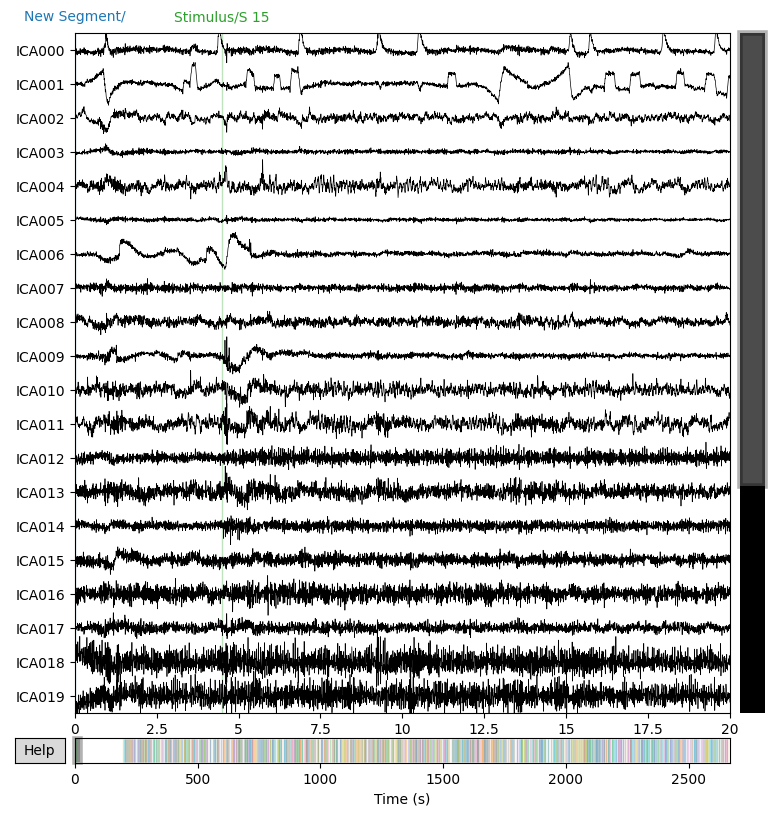

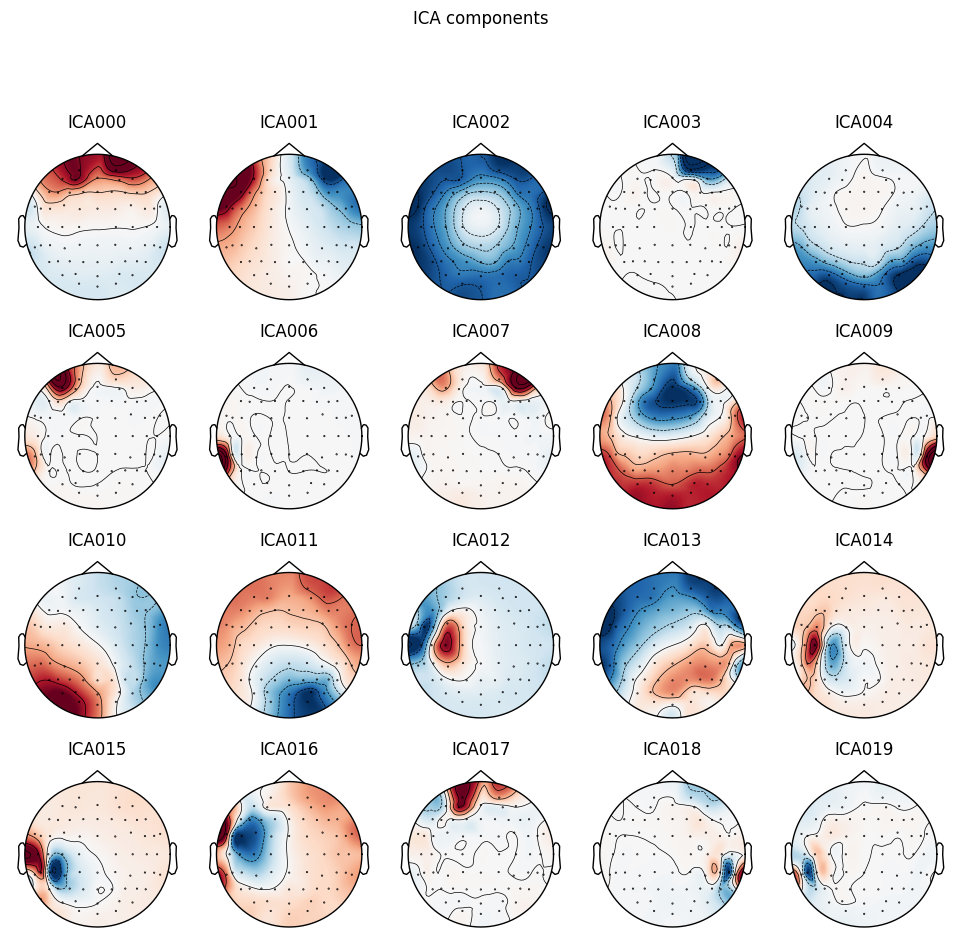

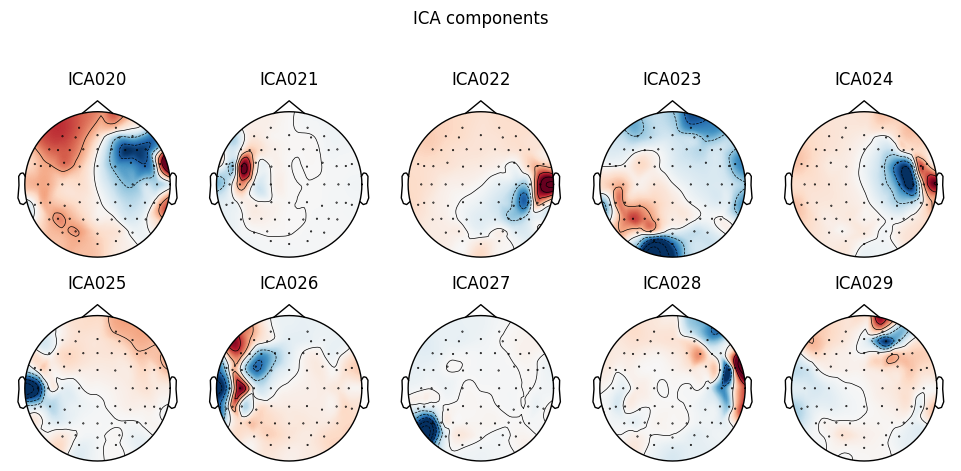

In [211]:
# ica独立成分分析
ica = ICA(n_components=30, random_state=97)
ica.fit(raw_interpolate)
ica.plot_sources(raw_interpolate)
ica.plot_components()
plt.show()

In [212]:
exc=[0,1,2,3,5,7,17]

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
1334 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1334 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1334 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1334 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1334 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1334 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1334 matching events found
No baseline correction applied
0 projection items activated


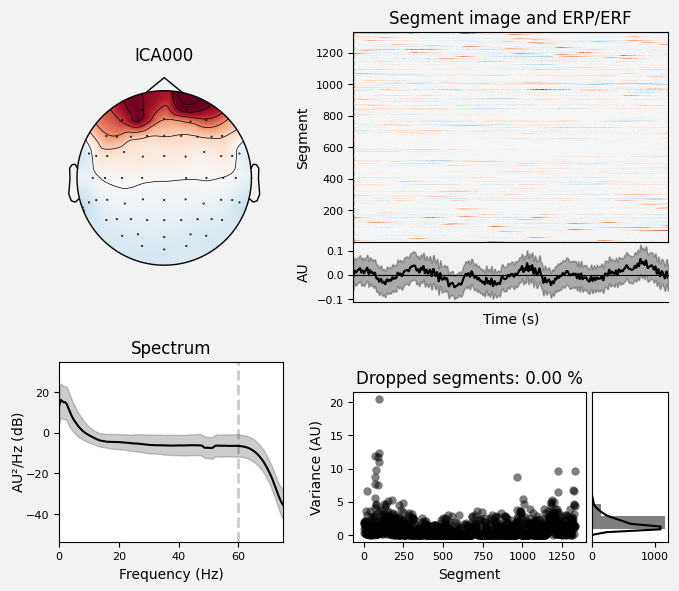

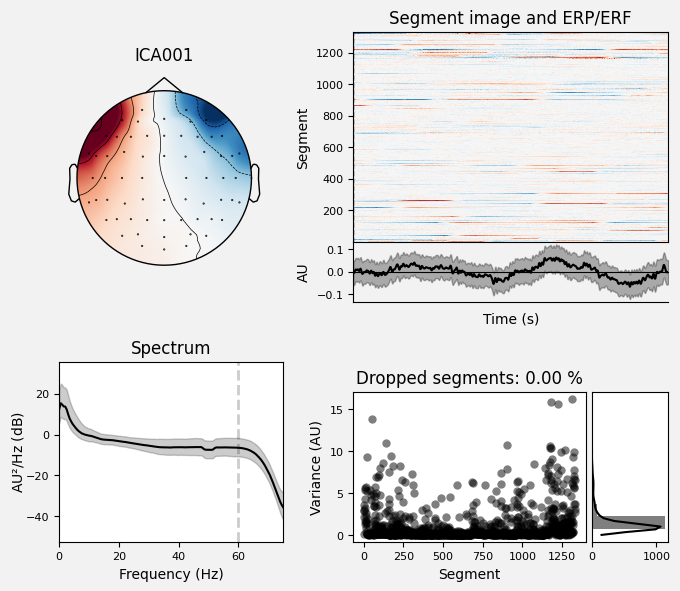

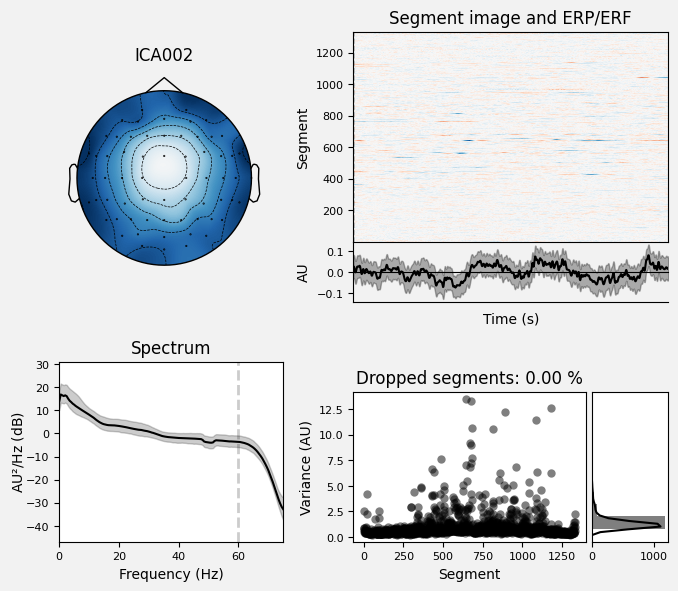

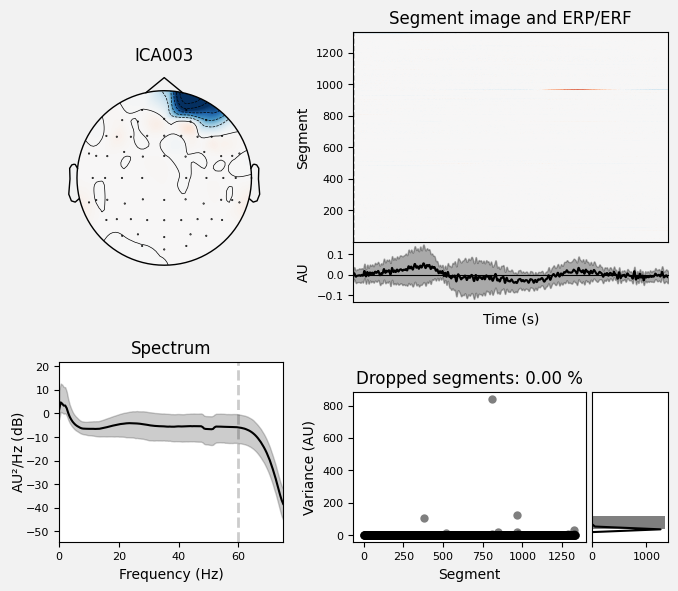

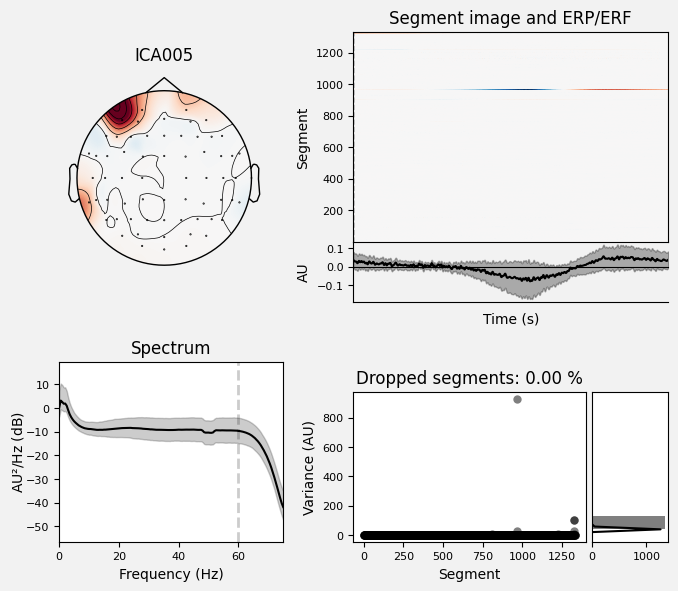

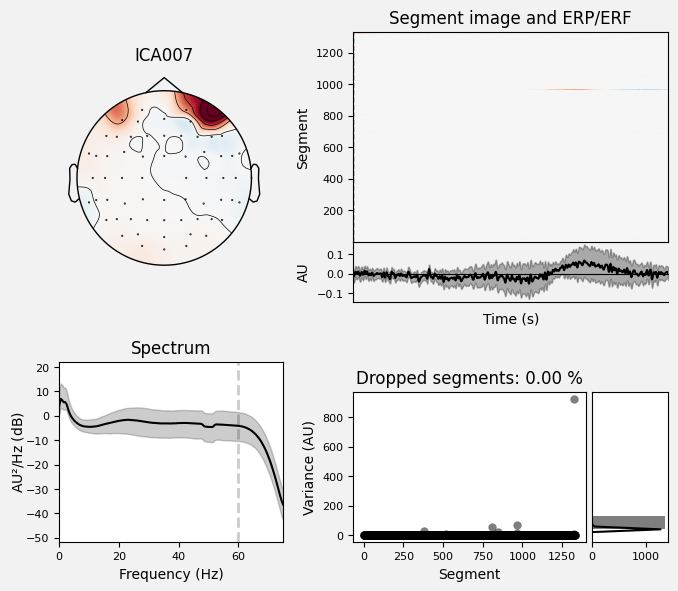

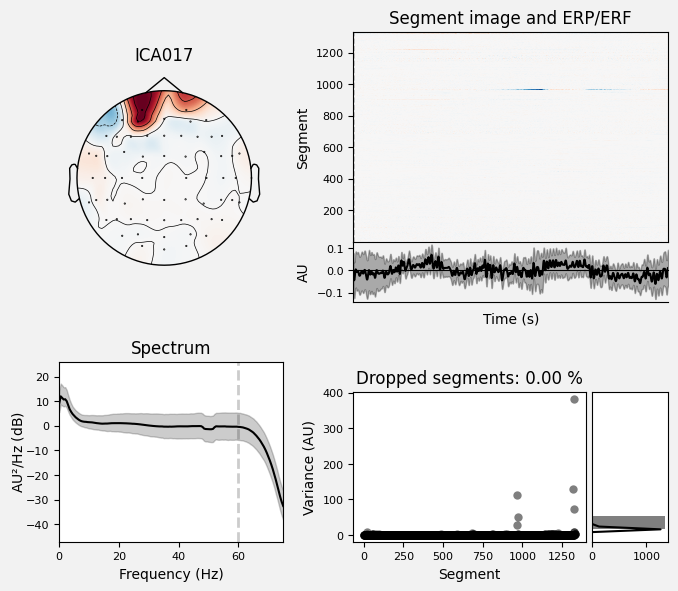

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [213]:
ica.plot_properties(raw_interpolate, picks=exc)

In [215]:
#剔除
exclude_id = exc
ica.exclude = exclude_id

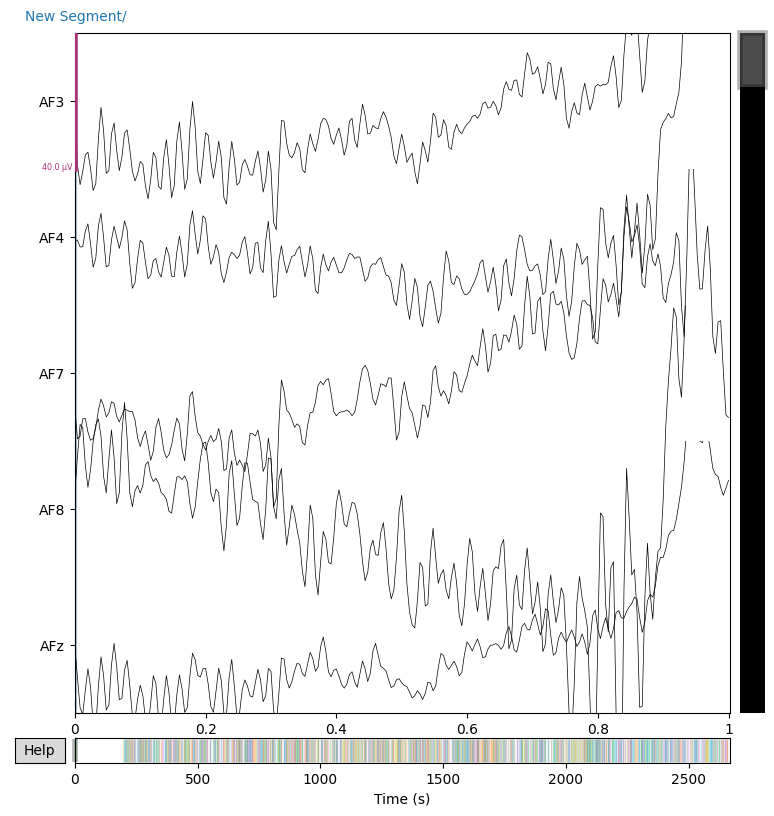

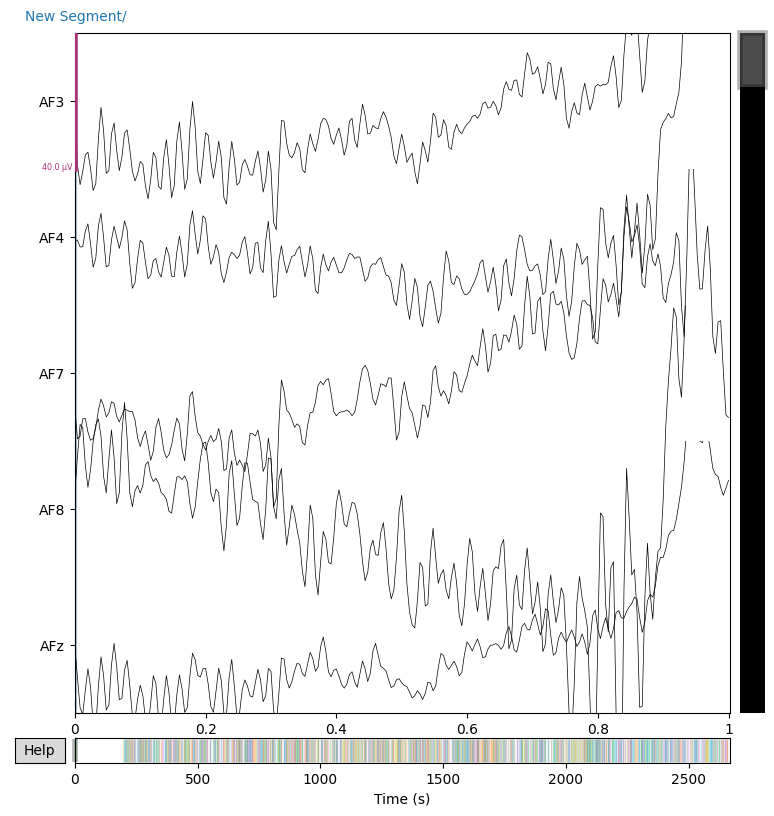

In [216]:
raw_raw.plot(start=0, duration=1, n_channels=5, title='ICA处理前')

Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 7 ICA components
    Projecting back using 63 PCA components


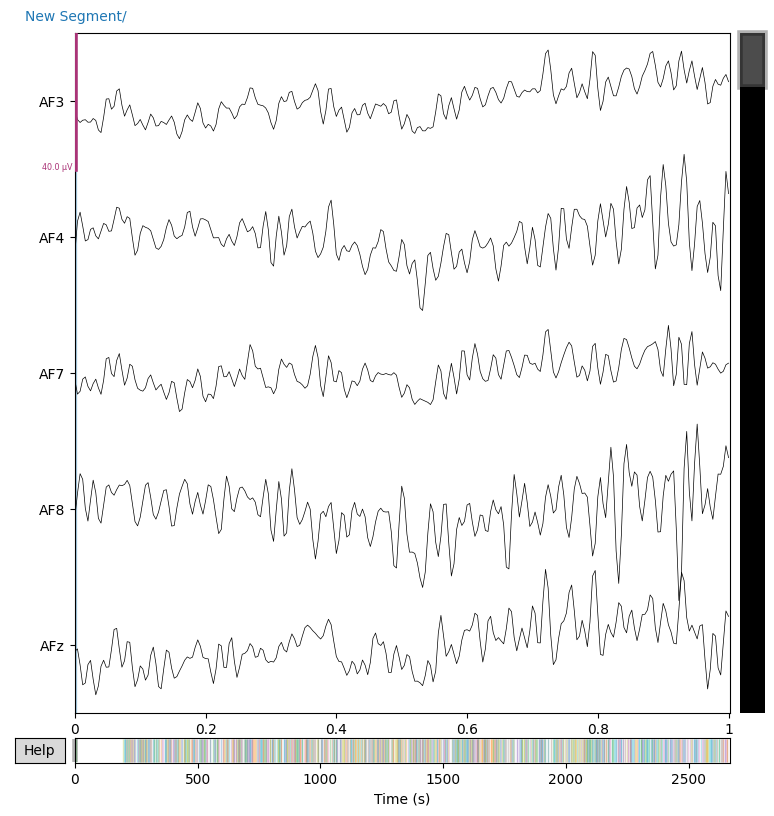

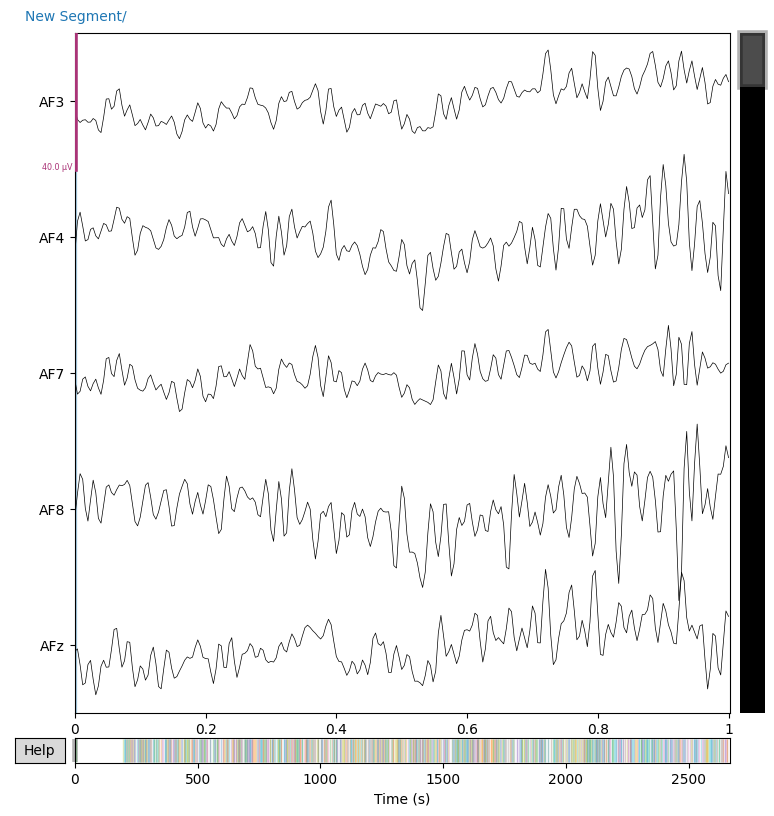

In [217]:
raw_recons = ica.apply(raw_interpolate)
raw_recons.plot(start=0, duration=1, n_channels=5, title='ICA处理后')

In [218]:
events = mne.events_from_annotations(raw_recons)
print(events)

Used Annotations descriptions: ['New Segment/', 'Response/R  1', 'Response/R  2', 'Response/R  3', 'Response/R  4', 'Response/R  5', 'Response/R  6', 'Response/R  7', 'Response/R  8', 'Response/R  9', 'Response/R 10', 'Response/R 11', 'Response/R 12', 'Response/R 13', 'Response/R 14', 'Response/R 15', 'Stimulus/S  1', 'Stimulus/S  2', 'Stimulus/S  3', 'Stimulus/S  4', 'Stimulus/S  5', 'Stimulus/S  6', 'Stimulus/S  7', 'Stimulus/S  8', 'Stimulus/S  9', 'Stimulus/S 10', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 14', 'Stimulus/S 15']
(array([[      0,       0,   99999],
       [   2247,       0,      15],
       [  97796,       0,    1007],
       ...,
       [1326218,       0,       8],
       [1327477,       0,       7],
       [1328743,       0,      14]]), {'New Segment/': 99999, 'Response/R  1': 1001, 'Response/R  2': 1002, 'Response/R  3': 1003, 'Response/R  4': 1004, 'Response/R  5': 1005, 'Response/R  6': 1006, 'Response/R  7': 1007, 'Response/R  8': 1008, 'Response/R  9': 100

In [219]:
date=file_name[0:6]
print(date)

0423-2


In [220]:
# 图片切分
x = 0
y = 12
for x in range(y):
    if x == 0:
        epochs_name = "Stimulus/S  1"
        out_file = "epoch/建筑/足球场/"+date+"-ver1-2-1-zqc.mat"
    elif x == 1:
        epochs_name = "Stimulus/S  2"
        out_file = "epoch/建筑/东京塔/"+date+"-ver1-2-1-djt.mat"
    elif x == 2:
        epochs_name="Stimulus/S  3"
        out_file="epoch/建筑/实验室/"+date+"-ver1-2-1-shysh.mat"
    elif x == 3:
        epochs_name="Stimulus/S  4"
        out_file="epoch/人物/爱因斯坦/"+date+"-ver1-2-1-ayst.mat"
    elif x == 4:
        epochs_name="Stimulus/S  5"
        out_file="epoch/人物/梅西/"+date+"-ver1-2-1-mx.mat"
    elif x == 5:
        epochs_name="Stimulus/S  6"
        out_file="epoch/人物/成龙/"+date+"-ver1-2-1-jc.mat"
    elif x == 6:
        epochs_name="Stimulus/S  7"
        out_file="epoch/水果/香蕉/"+date+"-ver1-2-1-bnn.mat"
    elif x == 7:
        epochs_name="Stimulus/S  8"
        out_file="epoch/水果/橘子/"+date+"-ver1-2-1-org.mat"
    elif x == 8:
        epochs_name="Stimulus/S  9"
        out_file="epoch/水果/西瓜/"+date+"-ver1-2-1-wtm.mat"
    elif x == 9:
        epochs_name="Stimulus/S 10"
        out_file="epoch/运动/羽毛球/"+date+"-ver1-2-1-btm.mat"
    elif x == 10:
        epochs_name="Stimulus/S 11"
        out_file="epoch/运动/游泳/"+date+"-ver1-2-1-swm.mat"
    elif x == 11:
        epochs_name="Stimulus/S 12"
        out_file="epoch/运动/篮球/"+date+"-ver1-2-1-bsk.mat"
    else :
        break
    print(raw_recons.info)
    epochs = mne.Epochs(raw_recons,events[0], event_id= events[1], preload=True, tmax=0.898, tmin=-0.1)
    print("epochs.plot")
    print(epochs)
    #epochs.plot(events=events[0], block=True)
    # 提取单独标签
    epochs_data = epochs[epochs_name].get_data()
    print(epochs_data.shape)
    evoked = epochs.average()
    #print("evoked.plot")
    #evoked.plot()
    # 提取数据与标签
    data = epochs[epochs_name].get_data()
    tag = events[0][1:,2]
    print("data.shape")
    print(data.shape)
    print("tag.shape")
    print(tag.shape)
    # 保存
    print("evoked")
    print(evoked)
    print(type(epochs_data))
    print(epochs_data.shape)
    # oned_as:{‘row’, ‘column’}, optional If ‘column’, write 1-D NumPy arrays as column vectors. If ‘row’, write 1-D NumPy arrays as row vectors.
    scipy.io.savemat(out_file,dict(epochs_data=epochs_data))

#名词切分
x=0
y=12
for x in range(y):
    print("#名词切分")
    if x==0:
        epochs_name="Response/R  1"
        out_file="epoch/名詞/足球场/"+date+"-ver1-2-1-zqc-n-"
    elif x==1:
        epochs_name="Response/R  2"
        out_file="epoch/名詞/东京塔/"+date+"-ver1-2-1-djt-n-"
    elif x==2:
        epochs_name="Response/R  3"
        out_file="epoch/名詞/实验室/"+date+"-ver1-2-1-shysh-n-"
    elif x==3:
        epochs_name="Response/R  4"
        out_file="epoch/名詞/爱因斯坦/"+date+"-ver1-2-1-ayst-n-"
    elif x==4:
        epochs_name="Response/R  5"
        out_file="epoch/名詞/梅西/"+date+"-ver1-2-1-mx-n-"
    elif x==5:
        epochs_name="Response/R  6"
        out_file="epoch/名詞/成龙/"+date+"-ver1-2-1-jc-n-"
    elif x==6:
        epochs_name="Response/R  7"
        out_file="epoch/名詞/香蕉/"+date+"-ver1-2-1-bnn-n-"
    elif x==7:
        epochs_name="Response/R  8"
        out_file="epoch/名詞/橘子/"+date+"-ver1-2-1-org-n-"
    elif x==8:
        epochs_name="Response/R  9"
        out_file="epoch/名詞/西瓜/"+date+"-ver1-2-1-wtm-n-"
    elif x==9:
        epochs_name="Response/R 10"
        out_file="epoch/名詞/羽毛球/"+date+"-ver1-2-1-btm-n-"
    elif x==10:
        epochs_name="Response/R 11"
        out_file="epoch/名詞/游泳/"+date+"-ver1-2-1-swm-n-"
    elif x==11:
        epochs_name="Response/R 12"
        out_file="epoch/名詞/篮球/"+date+"-ver1-2-1-bsk-n-"
    else:
        break
    i=0.0
    a=0
    x=16
    for a in range(x):
        print(raw_recons.info)
        epochs = mne.Epochs(raw_recons,events[0], event_id=events[1], preload=True, tmax=i+0.998, tmin=i, baseline=(i,i+0.998))
        i=i+0.25
        print("epochs.plot")
        print(epochs)
        #epochs.plot(events=events[0], block=True)
        # 提取单独标签
        epochs_data = epochs[epochs_name].get_data()
        print(epochs_data.shape)
        evoked = epochs.average()
        #print("evoked.plot")
        #evoked.plot()
        # 提取数据与标签
        data = epochs[epochs_name].get_data()
        tag = events[0][1:,2]
        print("data.shape")
        print(data.shape)
        print("tag.shape")
        print(tag.shape)
        # 保存
        print("evoked")
        print(evoked)
        print(type(epochs_data))
        print(epochs_data.shape)
        # oned_as:{‘row’, ‘column’}, optional If ‘column’, write 1-D NumPy arrays as column vectors. If ‘row’, write 1-D NumPy arrays as row vectors.
        scipy.io.savemat(out_file+str(a)+".mat",dict(epochs_data=epochs_data))

# 脚本
x=0
y=3
for x in range(y):
    print("#脚本切分")
    if x==0:
        epochs_name="Response/R 13"
        out_file="epoch/脚本/1/"+date+"-ver1-2-1-jb-"
    elif x == 1:
        epochs_name="Response/R 14"
        out_file="epoch/脚本/2/"+date+"-ver1-2-1-jb-"
    elif x == 2:
        epochs_name="Response/R 15"
        out_file="epoch/脚本/3/"+date+"-ver1-2-1-jb-"
    else:
        break
    i=0.0
    a=0
    x=3
    for a in range(x):
        print(raw_recons.info)
        epochs = mne.Epochs(raw_recons,events[0], event_id= events[1], preload=True, tmax=i+2.598, tmin=i, baseline=(i,i+2.598))
        i=i+2.598
        print("epochs.plot")
        print(epochs)
        #epochs.plot(events=events[0], block=True)
        # 提取单独标签
        epochs_data = epochs[epochs_name].get_data()
        print(epochs_data.shape)
        evoked = epochs.average()
        #print("evoked.plot")
        #evoked.plot()
        # 提取数据与标签
        data = epochs[epochs_name].get_data()
        tag = events[0][1:,2]
        print("data.shape")
        print(data.shape)
        print("tag.shape")
        print(tag.shape)
        # 保存
        print("evoked")
        print(evoked)
        print(type(epochs_data))
        print(epochs_data.shape)
        # oned_as:{‘row’, ‘column’}, optional If ‘column’, write 1-D NumPy arrays as column vectors. If ‘row’, write 1-D NumPy arrays as row vectors.
        scipy.io.savemat(out_file+str(a)+".mat",dict(epochs_data=epochs_data))

<Info | 8 non-empty values
 bads: []
 ch_names: AF3, AF4, AF7, AF8, AFz, C1, C2, C3, C4, C5, C6, CP1, CP2, CP3, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 1.0 Hz
 lowpass: 60.0 Hz
 meas_date: 2013-06-09 16:51:10 UTC
 nchan: 63
 projs: []
 sfreq: 500.0 Hz
>
Not setting metadata
753 matching events found
Setting baseline interval to [-0.1, 0.0] sec
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 753 events and 500 original time points ...
1 bad epochs dropped
epochs.plot
<Epochs |  752 events (all good), -0.1 - 0.898 sec, baseline -0.1 – 0 sec, ~180.8 MB, data loaded,
 'New Segment/': 0
 'Response/R  1': 10
 'Response/R  2': 10
 'Response/R  3': 10
 'Response/R  4': 10
 'Response/R  5': 10
 'Response/R  6': 10
 'Response/R  7': 10
 'Response/R  8': 10
 'Response/R  9': 10
 and 20 more events ...>
(50, 63, 500)
data.shape
(50, 63, 500)
tag.shape
(752,)
evoked
<Evoked | '0.00 × New Segm